# 01｜样本与固定月份合约序列

## 在做什么与经济意义

这一步建立后续所有统计项目共同使用的研究对象：对每个交易月选择**交易月后第 3 个月交割**的固定月份合约，并把 AL、CU、FU 与 RB 映射到逐日合约序列。

经济上，这种固定到期距离的选择控制了剩余期限，使不同日期的流动性和波动更可比；它也避免用成交量事后选择主力合约所带来的内生换月。换月处只标记 `is_roll_day`，不复权、不伪造连续价格。

本 Notebook 输出：研究样本日历、目标合约映射、FU 两个独立阶段、日盘 Session 覆盖、换月事件和可复核门禁。只读正式 silver，不调用 API，也不写任何湖仓、缓存或中间文件。

## 论文对应与当前复现等级

- 对应论文样本构造部分与 Table 1 的固定交割月选择逻辑。
- AL、CU、FU 是论文品种；RB 是论文外扩展，必须单独标注。SR 因正式湖仓没有分钟事实而不进入本项目研究宇宙。
- 当前复现等级是**方法框架复现**：数据来自 JQData 正式湖仓，样本从 2010 年开始，不声称复现 GTA 原数值。
- FU 旧产品段和稳定重启段独立构造，绝不跨停牌期连接合约或收益。
- 基线服从真实日盘 Session，排除夜盘；本 Notebook 只验证 Session 日历，尚不读取分钟事实或价格。

## 代码分为几个步骤

1. 定位项目根目录，确认正在使用 `latitude_env_v2` 解释器并导入权威 Schema。
2. 用统一浏览器展示本项直接涉及的品种日历和合约 Session 日历契约。
3. 固定五条研究序列及样本端点。
4. 直接用 PyArrow 分区/字段过滤读取两张 silver 表的必要列。
5. 解析固定月份合约代码，逐日匹配交易月后第 3 个月交割的合约。
6. 显式记录无法匹配的目标合约日，构造换月标记和 FU 独立序列。
7. 输出覆盖、换月图和独立门禁；所有结果只保存在 Notebook 输出中。

In [1]:
from __future__ import annotations

from datetime import date
import pathlib
import sys

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude_env_v2\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude_env_v2 环境：期望 {expected_python}，实际 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 开篇 Schema metadata 浏览器

下方组件是 `config/data_contracts.py` 权威 Schema 的只读投影。顺序按上游品种日历在前、合约 Session 日历在后排列；切换下拉框可查看表级 metadata、字段目录和单字段完整 metadata。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0


## 参数与固定样本

日期端点和 FU 分段是项目冻结口径。`sample_start` / `sample_end` 定义研究边界；它们不预先假设区间内每个交易日一定存在目标固定月份合约。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), "论文品种｜旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), "论文品种｜稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
display(sample_spec_df)

,series_id,underlying_code,sample_start,sample_end,research_role
0,AL,AL,2010-01-04,2026-08-28,论文品种
1,CU,CU,2010-01-04,2026-08-28,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,论文品种｜旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,论文品种｜稳定重启段
4,RB,RB,2010-01-04,2026-08-28,论文外扩展品种


## 直接读取正式 silver

表名、主键和 Hive 分区顺序从 Schema metadata 各读取一次。字段投影 Schema 直接由权威 Schema 的 Field 组成，用于在窄列读取后继续执行类型、nullable 和 Arrow→Pandas 契约验证。

读取过滤同时限制交易所、年份、品种和冻结日期；FU 只读取两个研究阶段。

In [4]:
variety_schema_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in FUTURES_VARIETY_CALENDAR_SCHEMA.metadata.items()
}
variety_table_name = variety_schema_metadata["table_name"]
variety_primary_key = variety_schema_metadata["primary_key"].split(",")
variety_partition_columns = variety_schema_metadata["partition_columns"].split(",")
variety_table_path = settings.futures_lake_root / "silver" / variety_table_name

variety_partitioning = ds.partitioning(
    pa.schema(
        [
            FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
            for column_name in variety_partition_columns
        ]
    ),
    flavor="hive",
)
variety_dataset = ds.dataset(
    variety_table_path,
    format="parquet",
    partitioning=variety_partitioning,
)

variety_physical_mismatches = []
for expected_field in FUTURES_VARIETY_CALENDAR_SCHEMA:
    actual_field = variety_dataset.schema.field(expected_field.name)
    if (
        actual_field.type != expected_field.type
        or actual_field.nullable != expected_field.nullable
    ):
        variety_physical_mismatches.append(
            {
                "field": expected_field.name,
                "expected_type": str(expected_field.type),
                "actual_type": str(actual_field.type),
                "expected_nullable": expected_field.nullable,
                "actual_nullable": actual_field.nullable,
            }
        )
if variety_physical_mismatches:
    raise TypeError(variety_physical_mismatches)

trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name) for column_name in variety_columns]
)
variety_calendar_table = variety_dataset.to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)
variety_calendar_df = variety_calendar_df.sort_values(
    ["underlying_code", "trading_date"],
    ignore_index=True,
)

display(
    pd.DataFrame(
        [
            {
                "table_name": variety_table_name,
                "primary_key": ",".join(variety_primary_key),
                "partition_columns": ",".join(variety_partition_columns),
                "projected_columns": ",".join(variety_columns),
                "rows_read": len(variety_calendar_df),
                "physical_mismatch_count": len(variety_physical_mismatches),
            }
        ]
    )
)

,table_name,primary_key,partition_columns,projected_columns,rows_read,physical_mismatch_count
0,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month","underlying_code,exchange_code,trading_date,active_contract_count",14175,0


In [5]:
contract_schema_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata.items()
}
contract_table_name = contract_schema_metadata["table_name"]
contract_primary_key = contract_schema_metadata["primary_key"].split(",")
contract_partition_columns = contract_schema_metadata["partition_columns"].split(",")
contract_table_path = settings.futures_lake_root / "silver" / contract_table_name

contract_partitioning = ds.partitioning(
    pa.schema(
        [
            FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
            for column_name in contract_partition_columns
        ]
    ),
    flavor="hive",
)
contract_dataset = ds.dataset(
    contract_table_path,
    format="parquet",
    partitioning=contract_partitioning,
)

contract_physical_mismatches = []
for expected_field in FUTURES_CONTRACT_CALENDAR_SCHEMA:
    actual_field = contract_dataset.schema.field(expected_field.name)
    if (
        actual_field.type != expected_field.type
        or actual_field.nullable != expected_field.nullable
    ):
        contract_physical_mismatches.append(
            {
                "field": expected_field.name,
                "expected_type": str(expected_field.type),
                "actual_type": str(actual_field.type),
                "expected_nullable": expected_field.nullable,
                "actual_nullable": actual_field.nullable,
            }
        )
if contract_physical_mismatches:
    raise TypeError(contract_physical_mismatches)

contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "list_date",
    "delist_date",
    "session_number",
    "session_text",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in contract_columns]
)
day_contract_filter = research_sample_filter & (ds.field("is_night_session") == False)
contract_calendar_table = contract_dataset.to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
for date_column in ["trading_date", "list_date", "delist_date"]:
    contract_calendar_df[date_column] = pd.to_datetime(contract_calendar_df[date_column])
contract_calendar_df = contract_calendar_df.sort_values(
    ["underlying_code", "trading_date", "contract_code", "session_start_at"],
    ignore_index=True,
)

display(
    pd.DataFrame(
        [
            {
                "table_name": contract_table_name,
                "primary_key": ",".join(contract_primary_key),
                "partition_columns": ",".join(contract_partition_columns),
                "projected_columns": ",".join(contract_columns),
                "day_session_rows_read": len(contract_calendar_df),
                "night_rows_after_filter": int(contract_calendar_df["is_night_session"].sum()),
                "physical_mismatch_count": len(contract_physical_mismatches),
            }
        ]
    )
)

,table_name,primary_key,partition_columns,projected_columns,day_session_rows_read,night_rows_after_filter,physical_mismatch_count
0,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month","contract_code,exchange_code,underlying_code,trading_date,list_date,delist_date,session_number,session_text,session_start_at,session_end_at,is_night_session,minute_count",508863,0,0


## 构造预期样本格点与目标交割月

品种日历给出冻结边界内应研究的交易日。对每一日，将交易月份加 3 得到目标交割年月，并按上期所固定月份代码 `品种 + YYMM + .XSGE` 构造预期合约代码。

In [6]:
expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_series_df["research_role"] = sample_spec.research_role
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = pd.PeriodIndex(
    expected_sample_df["trading_date"],
    freq="M",
) + 3
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(expected_trading_days="size", sample_first_date="min", sample_last_date="max")
    .reset_index()
)

,series_id,expected_trading_days,sample_first_date,sample_last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [7]:
contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(f"存在无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}")

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_code"] = contract_code_parts[1]
contract_calendar_df["code_exchange"] = contract_code_parts[2]
contract_calendar_df["delivery_year"] = (
    2000 + contract_calendar_df["delivery_code"].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_calendar_df["delivery_code"].str[2:].astype("int8")
)

contract_target_period = pd.PeriodIndex(
    contract_calendar_df["trading_date"],
    freq="M",
) + 3
contract_calendar_df["target_delivery_year"] = contract_target_period.year
contract_calendar_df["target_delivery_month"] = contract_target_period.month
contract_calendar_df["is_target_delivery"] = (
    (contract_calendar_df["delivery_year"] == contract_calendar_df["target_delivery_year"])
    & (contract_calendar_df["delivery_month"] == contract_calendar_df["target_delivery_month"])
)

assert (
    contract_calendar_df["code_underlying"] == contract_calendar_df["underlying_code"]
).all(), "合约代码中的品种与权威字段不一致"
assert (
    contract_calendar_df["code_exchange"] == contract_calendar_df["exchange_code"]
).all(), "合约代码中的交易所与权威字段不一致"
assert contract_calendar_df["delivery_month"].between(1, 12).all(), "交割月份越界"

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)

target_contract_day_df = (
    target_session_df.sort_values(
        ["underlying_code", "trading_date", "contract_code", "session_start_at"]
    )
    .groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "target_delivery_year",
            "target_delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        list_date=("list_date", "first"),
        delist_date=("delist_date", "first"),
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
        first_day_session_start=("session_start_at", "min"),
        last_day_session_end=("session_end_at", "max"),
        day_session_text=(
            "session_text",
            lambda values: " | ".join(values.astype("string").tolist()),
        ),
    )
    .reset_index()
)

display(
    target_contract_count_df["target_contract_count"]
    .value_counts()
    .sort_index()
    .rename_axis("target_contract_count")
    .rename("trading_day_count")
    .reset_index()
)

,target_contract_count,trading_day_count
0,1,14153


## 合约覆盖、显式排除与换月标记

目标合约不存在时，本项目不允许改选两个月或四个月合约，也不允许填补交易日。审计表保留预期合约代码和排除原因；实际合约序列只包含严格命中固定规则的日期。

In [8]:
contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    pd.to_numeric(contract_mapping_audit_df["target_contract_count"])
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all(), (
    "同一品种交易日出现多个交易月后第 3 个月交割合约"
)

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
    suffixes=("_expected", "_actual"),
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)

missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "underlying_code",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_mask = (
    (expected_sample_df["series_id"] == "FU_legacy")
    & (expected_sample_df["trading_date"].dt.to_period("M") == pd.Period("2010-11"))
)
known_missing_keys_df = expected_sample_df.loc[
    known_missing_mask,
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df.loc[
    :,
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df), (
    "出现计划外的目标合约缺口；必须人工核查，不能自动换合约"
)
assert set(actual_missing_keys_df["expected_contract_code"]) == {"FU1102.XSGE"}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = contract_series_df.groupby(
    "series_id",
    observed=True,
)["contract_code"].shift()
contract_changed = contract_series_df["contract_code"].ne(
    contract_series_df["previous_contract_code"]
).fillna(False)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna() & contract_changed
).astype("bool")
contract_series_df["roll_increment"] = contract_series_df["is_roll_day"].astype("int64")
contract_series_df["contract_sequence_number"] = (
    contract_series_df.groupby("series_id", observed=True)["roll_increment"].cumsum() + 1
)
contract_series_df = contract_series_df.drop(columns="roll_increment")
contract_series_df["expected_five_minute_slots"] = (
    pd.to_numeric(contract_series_df["day_minute_count"]).astype("int64") // 5
)
contract_series_df["delivery_month_ordinal"] = (
    pd.to_numeric(contract_series_df["delivery_year"]).astype("int64") * 12
    + pd.to_numeric(contract_series_df["delivery_month"]).astype("int64")
)
contract_series_df["previous_delivery_month_ordinal"] = contract_series_df.groupby(
    "series_id",
    observed=True,
)["delivery_month_ordinal"].shift()
contract_series_df["delivery_month_jump"] = (
    contract_series_df["delivery_month_ordinal"]
    - contract_series_df["previous_delivery_month_ordinal"]
)

display(missing_contract_mapping_df)

,series_id,underlying_code,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,FU,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,FU,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,FU,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,FU,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,FU,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,FU,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,FU,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,FU,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,FU,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,FU,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


In [9]:
expected_count_df = (
    expected_sample_df.groupby("series_id", observed=True)
    .agg(
        expected_trading_days=("trading_date", "size"),
        expected_first_date=("trading_date", "min"),
        expected_last_date=("trading_date", "max"),
    )
    .reset_index()
)
selected_summary_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
        min_day_sessions=("day_session_count", "min"),
        max_day_sessions=("day_session_count", "max"),
        min_day_minutes=("day_minute_count", "min"),
        max_day_minutes=("day_minute_count", "max"),
        min_five_minute_slots=("expected_five_minute_slots", "min"),
        max_five_minute_slots=("expected_five_minute_slots", "max"),
    )
    .reset_index()
)
sample_coverage_df = (
    sample_spec_df.merge(expected_count_df, on="series_id", validate="one_to_one")
    .merge(selected_summary_df, on="series_id", validate="one_to_one")
)
sample_coverage_df["excluded_days"] = (
    sample_coverage_df["expected_trading_days"]
    - sample_coverage_df["selected_trading_days"]
)
sample_coverage_df["coverage_pct"] = (
    100.0
    * sample_coverage_df["selected_trading_days"]
    / sample_coverage_df["expected_trading_days"]
).round(4)

coverage_columns = [
    "series_id",
    "research_role",
    "sample_start",
    "sample_end",
    "expected_trading_days",
    "selected_trading_days",
    "excluded_days",
    "coverage_pct",
    "first_selected_date",
    "last_selected_date",
    "unique_contracts",
    "roll_days",
    "min_day_sessions",
    "max_day_sessions",
    "min_day_minutes",
    "max_day_minutes",
    "min_five_minute_slots",
    "max_five_minute_slots",
]
display(sample_coverage_df[coverage_columns])

roll_event_df = contract_series_df.loc[
    contract_series_df["is_roll_day"],
    [
        "series_id",
        "trading_date",
        "previous_contract_code",
        "contract_code",
        "delivery_month_jump",
    ],
].copy()
display(roll_event_df.groupby("series_id", observed=True).head(3))

,series_id,research_role,sample_start,sample_end,expected_trading_days,selected_trading_days,excluded_days,coverage_pct,first_selected_date,last_selected_date,unique_contracts,roll_days,min_day_sessions,max_day_sessions,min_day_minutes,max_day_minutes,min_five_minute_slots,max_five_minute_slots
0,AL,论文品种,2010-01-04,2026-08-28,4045,4045,0,100.0000,2010-01-04,2026-08-28,200,199,3.0,3.0,225,225,45,45
1,CU,论文品种,2010-01-04,2026-08-28,4045,4045,0,100.0000,2010-01-04,2026-08-28,200,199,3.0,3.0,225,225,45,45
2,FU_legacy,论文品种｜旧产品段,2010-01-04,2011-09-30,426,404,22,94.8357,2010-01-04,2011-09-30,20,19,3.0,3.0,225,225,45,45
3,FU_relaunched,论文品种｜稳定重启段,2020-01-02,2026-08-28,1614,1614,0,100.0000,2020-01-02,2026-08-28,80,79,3.0,3.0,225,225,45,45
4,RB,论文外扩展品种,2010-01-04,2026-08-28,4045,4045,0,100.0000,2010-01-04,2026-08-28,200,199,3.0,3.0,225,225,45,45


,series_id,trading_date,previous_contract_code,contract_code,delivery_month_jump
20,AL,2010-02-01,AL1004.XSGE,AL1005.XSGE,1.0
35,AL,2010-03-01,AL1005.XSGE,AL1006.XSGE,1.0
58,AL,2010-04-01,AL1006.XSGE,AL1007.XSGE,1.0
4065,CU,2010-02-01,CU1004.XSGE,CU1005.XSGE,1.0
4080,CU,2010-03-01,CU1005.XSGE,CU1006.XSGE,1.0
4103,CU,2010-04-01,CU1006.XSGE,CU1007.XSGE,1.0
8110,FU_legacy,2010-02-01,FU1004.XSGE,FU1005.XSGE,1.0
8125,FU_legacy,2010-03-01,FU1005.XSGE,FU1006.XSGE,1.0
8148,FU_legacy,2010-04-01,FU1006.XSGE,FU1007.XSGE,1.0
8510,FU_relaunched,2020-02-03,FU2004.XSGE,FU2005.XSGE,1.0


## 独立验证门禁

门禁只验证本研究算法新增的前提：样本边界、目标合约唯一性、已知缺口处理、日盘槽位能力、FU 分段和换月语义。它不重新扫描生产者已经保证的源表主键或全表连续性。

In [10]:
expected_bounds_df = (
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(actual_start="min", actual_end="max")
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_start", "sample_end"]],
        on="series_id",
        validate="one_to_one",
    )
)
selected_bounds_df = (
    contract_series_df.groupby("series_id", observed=True)["trading_date"]
    .agg(actual_start="min", actual_end="max")
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_start", "sample_end"]],
        on="series_id",
        validate="one_to_one",
    )
)
first_series_rows_df = contract_series_df.groupby("series_id", observed=True).head(1)
recomputed_roll_flag = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"]
    .ne(contract_series_df["previous_contract_code"])
    .fillna(False)
)
legacy_last_date = contract_series_df.loc[
    contract_series_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
relaunched_first_date = contract_series_df.loc[
    contract_series_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            not variety_physical_mismatches and not contract_physical_mismatches,
            f"variety={len(variety_physical_mismatches)}, contract={len(contract_physical_mismatches)}",
        ),
        (
            "research_series_exact",
            set(expected_sample_df["series_id"]) == set(sample_spec_df["series_id"]),
            ", ".join(sample_spec_df["series_id"]),
        ),
        (
            "fixed_sample_endpoints",
            (expected_bounds_df["actual_start"] == expected_bounds_df["sample_start"]).all()
            and (expected_bounds_df["actual_end"] == expected_bounds_df["sample_end"]).all(),
            "五条预期样本均命中冻结起止日",
        ),
        (
            "selected_series_keep_endpoints",
            (selected_bounds_df["actual_start"] == selected_bounds_df["sample_start"]).all()
            and (selected_bounds_df["actual_end"] == selected_bounds_df["sample_end"]).all(),
            "显式排除内部缺口后仍保留冻结端点",
        ),
        (
            "target_contract_at_most_one_per_day",
            contract_mapping_audit_df["target_contract_count"].isin([0, 1]).all(),
            "目标合约计数只允许 0 或 1",
        ),
        (
            "selected_contract_matches_trade_month_plus_three",
            (
                contract_series_df["contract_code"]
                == contract_series_df["expected_contract_code"]
            ).all(),
            "实际合约代码逐日等于预期 YYMM 代码",
        ),
        (
            "known_target_contract_gap_only",
            actual_missing_keys_df.equals(known_missing_keys_df),
            f"{len(actual_missing_keys_df)} 日，均为未上市的 FU1102.XSGE",
        ),
        (
            "day_sessions_only",
            not contract_calendar_df["is_night_session"].any(),
            "PyArrow 读取过滤已排除全部夜盘 Session",
        ),
        (
            "three_real_day_sessions",
            contract_series_df["day_session_count"].eq(3).all(),
            "09:00–10:15｜10:30–11:30｜13:30–15:00",
        ),
        (
            "day_minutes_and_five_minute_capacity",
            contract_series_df["day_minute_count"].eq(225).all()
            and contract_series_df["expected_five_minute_slots"].eq(45).all(),
            "225 个真实交易分钟，可形成 45 个五分钟槽位",
        ),
        (
            "roll_flag_matches_contract_change",
            contract_series_df["is_roll_day"].equals(recomputed_roll_flag.astype("bool")),
            "只在同一独立序列内合约代码变化时标记",
        ),
        (
            "first_row_is_not_roll",
            not first_series_rows_df["is_roll_day"].any(),
            "每条独立序列首日不与外部样本连接",
        ),
        (
            "fu_segments_do_not_connect",
            legacy_last_date < relaunched_first_date,
            f"legacy_end={legacy_last_date.date()}, relaunched_start={relaunched_first_date.date()}",
        ),
        (
            "roll_delivery_month_moves_forward",
            roll_event_df["delivery_month_jump"].gt(0).all(),
            "缺失 FU1102 时允许从 FU1101 前进两个月至 FU1103，不做替代",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"variety=0, contract=0"
2,research_series_exact,True,"AL, CU, FU_legacy, FU_relaunched, RB"
3,fixed_sample_endpoints,True,五条预期样本均命中冻结起止日
4,selected_series_keep_endpoints,True,显式排除内部缺口后仍保留冻结端点
5,target_contract_at_most_one_per_day,True,目标合约计数只允许 0 或 1
6,selected_contract_matches_trade_month_plus_three,True,实际合约代码逐日等于预期 YYMM 代码
7,known_target_contract_gap_only,True,22 日，均为未上市的 FU1102.XSGE
8,day_sessions_only,True,PyArrow 读取过滤已排除全部夜盘 Session
9,three_real_day_sessions,True,09:00–10:15｜10:30–11:30｜13:30–15:00


## 换月时序图

点表示同一独立序列内固定月份合约发生变化的交易日。RB 用橙色单独标注；FU 两段分别占一行，因此不会在图上跨停牌期连接。

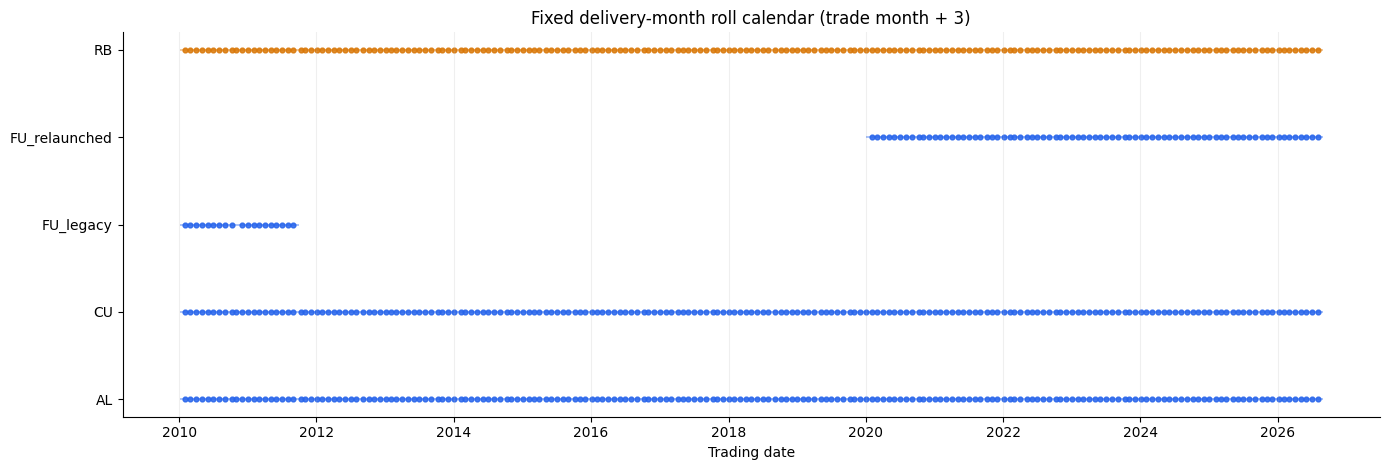

In [11]:
series_order = ["AL", "CU", "FU_legacy", "FU_relaunched", "RB"]
figure, axis = plt.subplots(figsize=(14, 4.8))
for series_position, series_id in enumerate(series_order):
    series_dates = contract_series_df.loc[
        contract_series_df["series_id"] == series_id,
        "trading_date",
    ]
    series_roll_dates = roll_event_df.loc[
        roll_event_df["series_id"] == series_id,
        "trading_date",
    ]
    series_color = "#d97706" if series_id == "RB" else "#2563eb"
    axis.hlines(
        series_position,
        series_dates.min(),
        series_dates.max(),
        color=series_color,
        linewidth=1.2,
        alpha=0.45,
    )
    axis.scatter(
        series_roll_dates,
        np.full(len(series_roll_dates), series_position),
        s=12,
        color=series_color,
        alpha=0.85,
    )

axis.set_yticks(range(len(series_order)), labels=series_order)
axis.set_xlabel("Trading date")
axis.set_title("Fixed delivery-month roll calendar (trade month + 3)")
axis.grid(axis="x", alpha=0.2)
axis.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
plt.show()

In [12]:
fu_legacy_coverage = sample_coverage_df.loc[
    sample_coverage_df["series_id"] == "FU_legacy",
    "coverage_pct",
].iloc[0]
display(
    Markdown(
        f"""
## 结果解释

- AL、CU、RB 与 FU 稳定重启段均能在冻结样本内逐日唯一命中交易月后第 3 个月交割合约。
- FU 旧产品段命中率为 **{fu_legacy_coverage:.4f}%**；2010 年 11 月的 22 个交易日预期 `FU1102.XSGE`，但该固定月份合约未上市，故严格排除。
- 所有入选日期均有 3 个真实日盘 Session、合计 225 个交易分钟，能够支持后续每日 45 个五分钟槽位。
- `is_roll_day` 只描述合约身份变化；价格在后续 Notebook 中直接连接且不复权。FU 两段从各自首日重新开始，停牌期两侧不相连。
- RB 是扩展序列，上表和图中始终与论文品种分开标注。
"""
    )
)


## 结果解释

- AL、CU、RB 与 FU 稳定重启段均能在冻结样本内逐日唯一命中交易月后第 3 个月交割合约。
- FU 旧产品段命中率为 **94.8357%**；2010 年 11 月的 22 个交易日预期 `FU1102.XSGE`，但该固定月份合约未上市，故严格排除。
- 所有入选日期均有 3 个真实日盘 Session、合计 225 个交易分钟，能够支持后续每日 45 个五分钟槽位。
- `is_roll_day` 只描述合约身份变化；价格在后续 Notebook 中直接连接且不复权。FU 两段从各自首日重新开始，停牌期两侧不相连。
- RB 是扩展序列，上表和图中始终与论文品种分开标注。


## 限制与下一步

- 本项只构造合约身份与 Session 能力，没有读取行情价格；因此尚未产生收益，也没有执行换月价格连接。
- `225 / 5 = 45` 是由权威 Session 日历得到的理论槽位能力，不等于分钟事实完整性证明；分钟事实覆盖将在真正使用分钟表的 Notebook 中单独验证。
- FU 旧产品段缺少 `FU1102.XSGE` 是固定规则下的经济对象缺失，不使用邻近合约替代。后续 Notebook 必须自包含地重算并继承同一显式排除。
- 样本来自 JQData 正式湖仓，不能解释为 GTA 原样本数值复刻。
- 本 Notebook 没有产生任何持久化研究中间文件。下一项 `02_delivery_month_volume_and_liquidity.ipynb` 将重新构造合约映射，并研究距交割 0—5 月合约的成交量与流动性。